In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [7]:
df.columns = df.columns.str.strip()
df.columns.tolist()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [8]:
print(df['education'].unique())
print(df['self_employed'].unique())
print(df['loan_status'].unique())

<StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str
<StringArray>
[' No', ' Yes']
Length: 2, dtype: str
<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [9]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

In [10]:
df['education'].unique()

<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

In [11]:
df['education'] = df['education'].map({'Graduate':1,'Not Graduate' : 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1,'No':0})
df['loan_status'] = df['loan_status'].map({'Approved':1,'Rejected':0})

In [12]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [13]:
df['loan_status'].value_counts()

loan_status
1    2656
0    1613
Name: count, dtype: int64

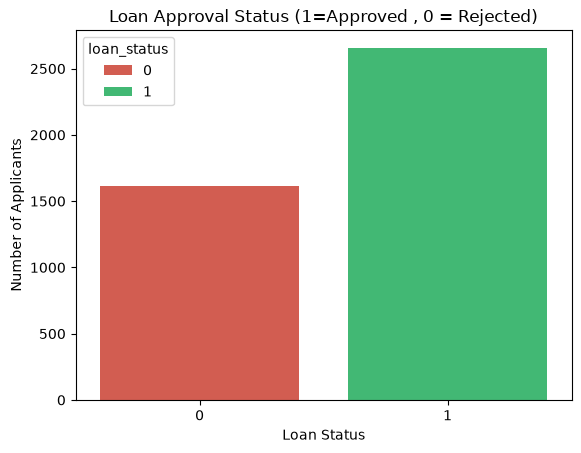

In [14]:
sns.countplot(x='loan_status',data=df,palette=['#e74c3c', '#2ECC71'],hue = 'loan_status',legend=True)
plt.title('Loan Approval Status (1=Approved , 0 = Rejected)')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applicants')
plt.show()

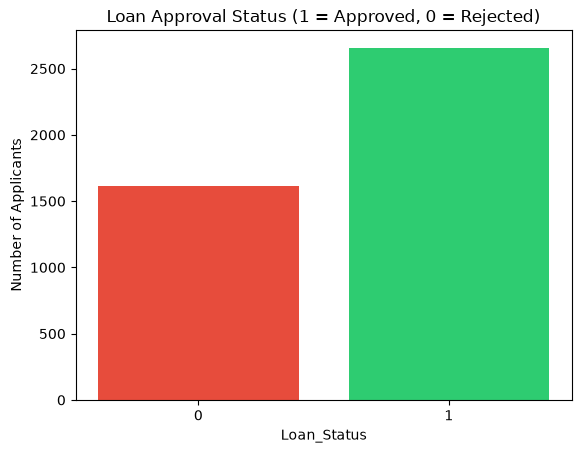

In [15]:
counts = df['loan_status'].value_counts()
plt.bar(counts.index,counts.values,color = ['#2ecc71', "#e74c3c"])
plt.title('Loan Approval Status (1 = Approved, 0 = Rejected)')
plt.xlabel('Loan_Status')
plt.ylabel('Number of Applicants')
plt.xticks([0,1])
plt.show()

In [16]:
import plotly.express as px

fig = px.bar(x=counts.index, y=counts.values, 
             color=counts.index.astype(str),
             color_discrete_map={'0': '#e74c3c', '1': '#2ecc71'},
             labels={'x': 'Loan Status', 'y': 'Number of Applicants'},
             title='Loan Approval Status (1 = Approved, 0 = Rejected)')
fig.show()

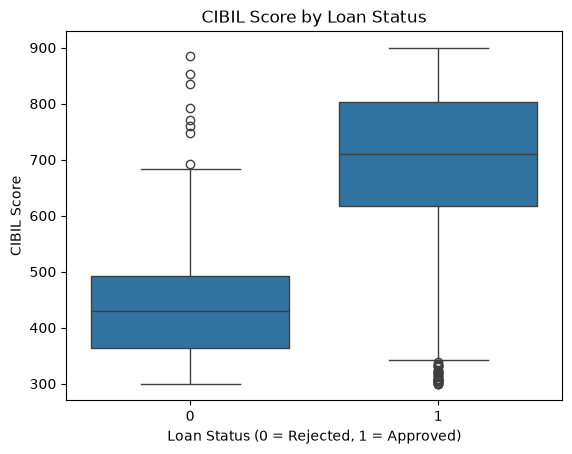

In [ ]:
sns.boxplot(x ='loan_status',y ='cibil_score',data=df)
plt.title('CIBIL Score by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('CIBIL Score')
plt.show()

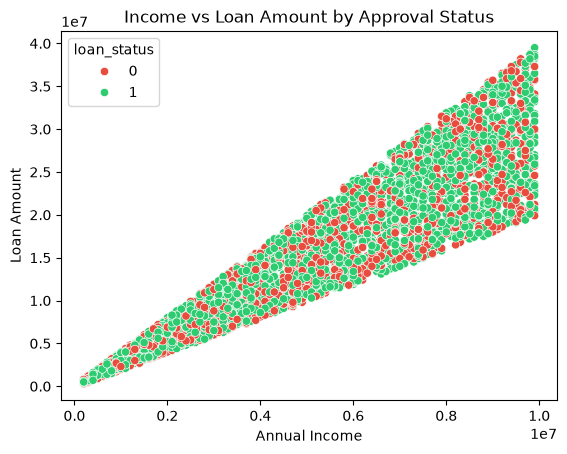

In [20]:
sns.scatterplot(x='income_annum',y='loan_amount',data=df,hue='loan_status',palette=['#e74c3c', '#2ecc71'])
plt.title('Income vs Loan Amount by Approval Status')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.show()